# 📊 01. Phân tích dữ liệu khám phá (EDA)


In [1]:
# Hợp nhất dữ liệu
payment_sum = payments.groupby('order_id')['payment_value'].sum().reset_index()
item_count = order_items.groupby('order_id').size().reset_index(name='item_count')
df = orders.merge(payment_sum, on='order_id', how='left')
df = df.merge(item_count, on='order_id', how='left')
df = df.merge(customers, on='customer_id', how='left')

# Định nghĩa biến mục tiêu
orders['is_return'] = orders['order_status'].apply(lambda x: 1 if x == 'canceled' else 0)
orders['Trả hàng'] = orders['is_return'].map({0: 'Không', 1: 'Có'})
df = df.merge(orders[['order_id', 'is_return', 'Trả hàng']], on='order_id', how='left')
df.head()

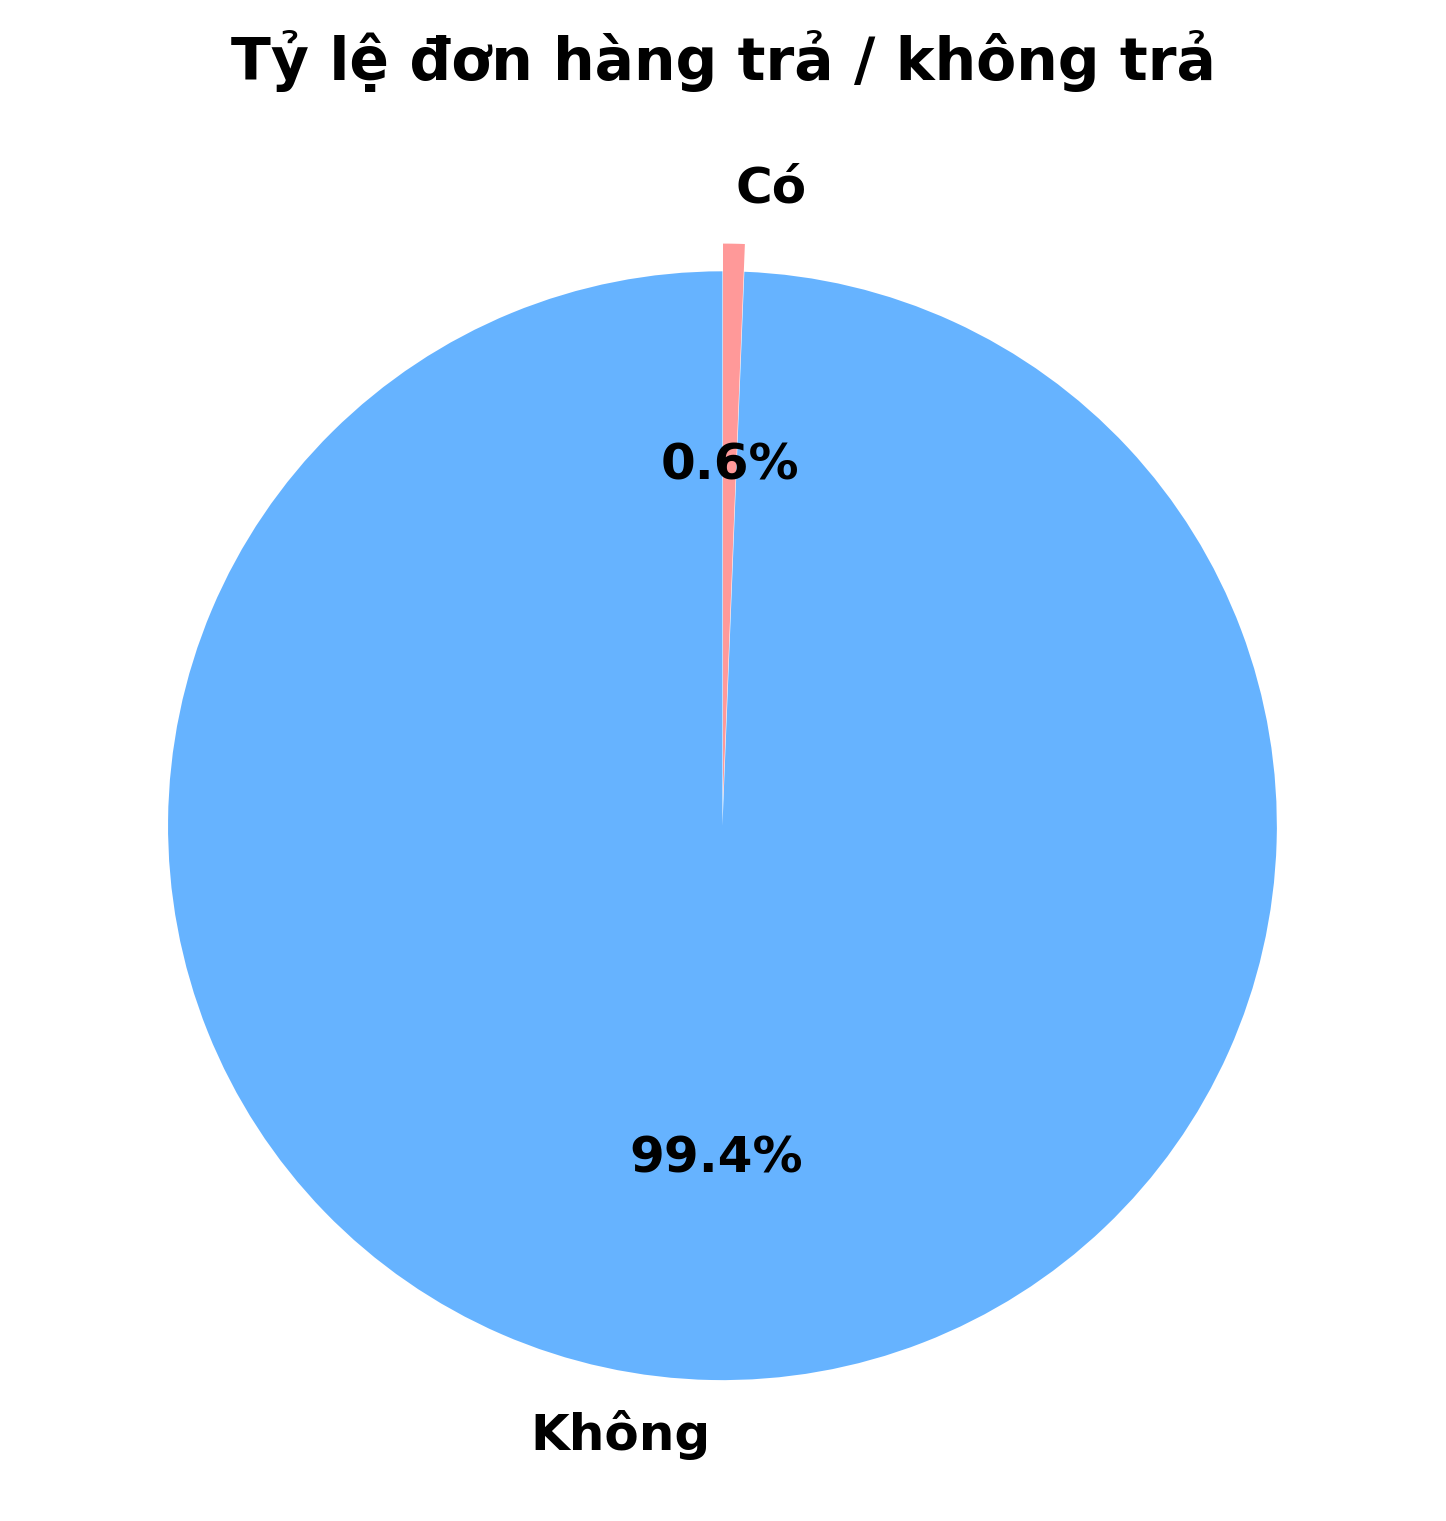

In [1]:
# Biểu đồ 5: Tỷ lệ %
plt.figure(figsize=(6,6))
counts = orders['Trả hàng'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'], explode=(0.05, 0), textprops={'fontweight': 'bold'})
plt.title('Tỷ lệ đơn hàng trả / không trả')
plt.show()

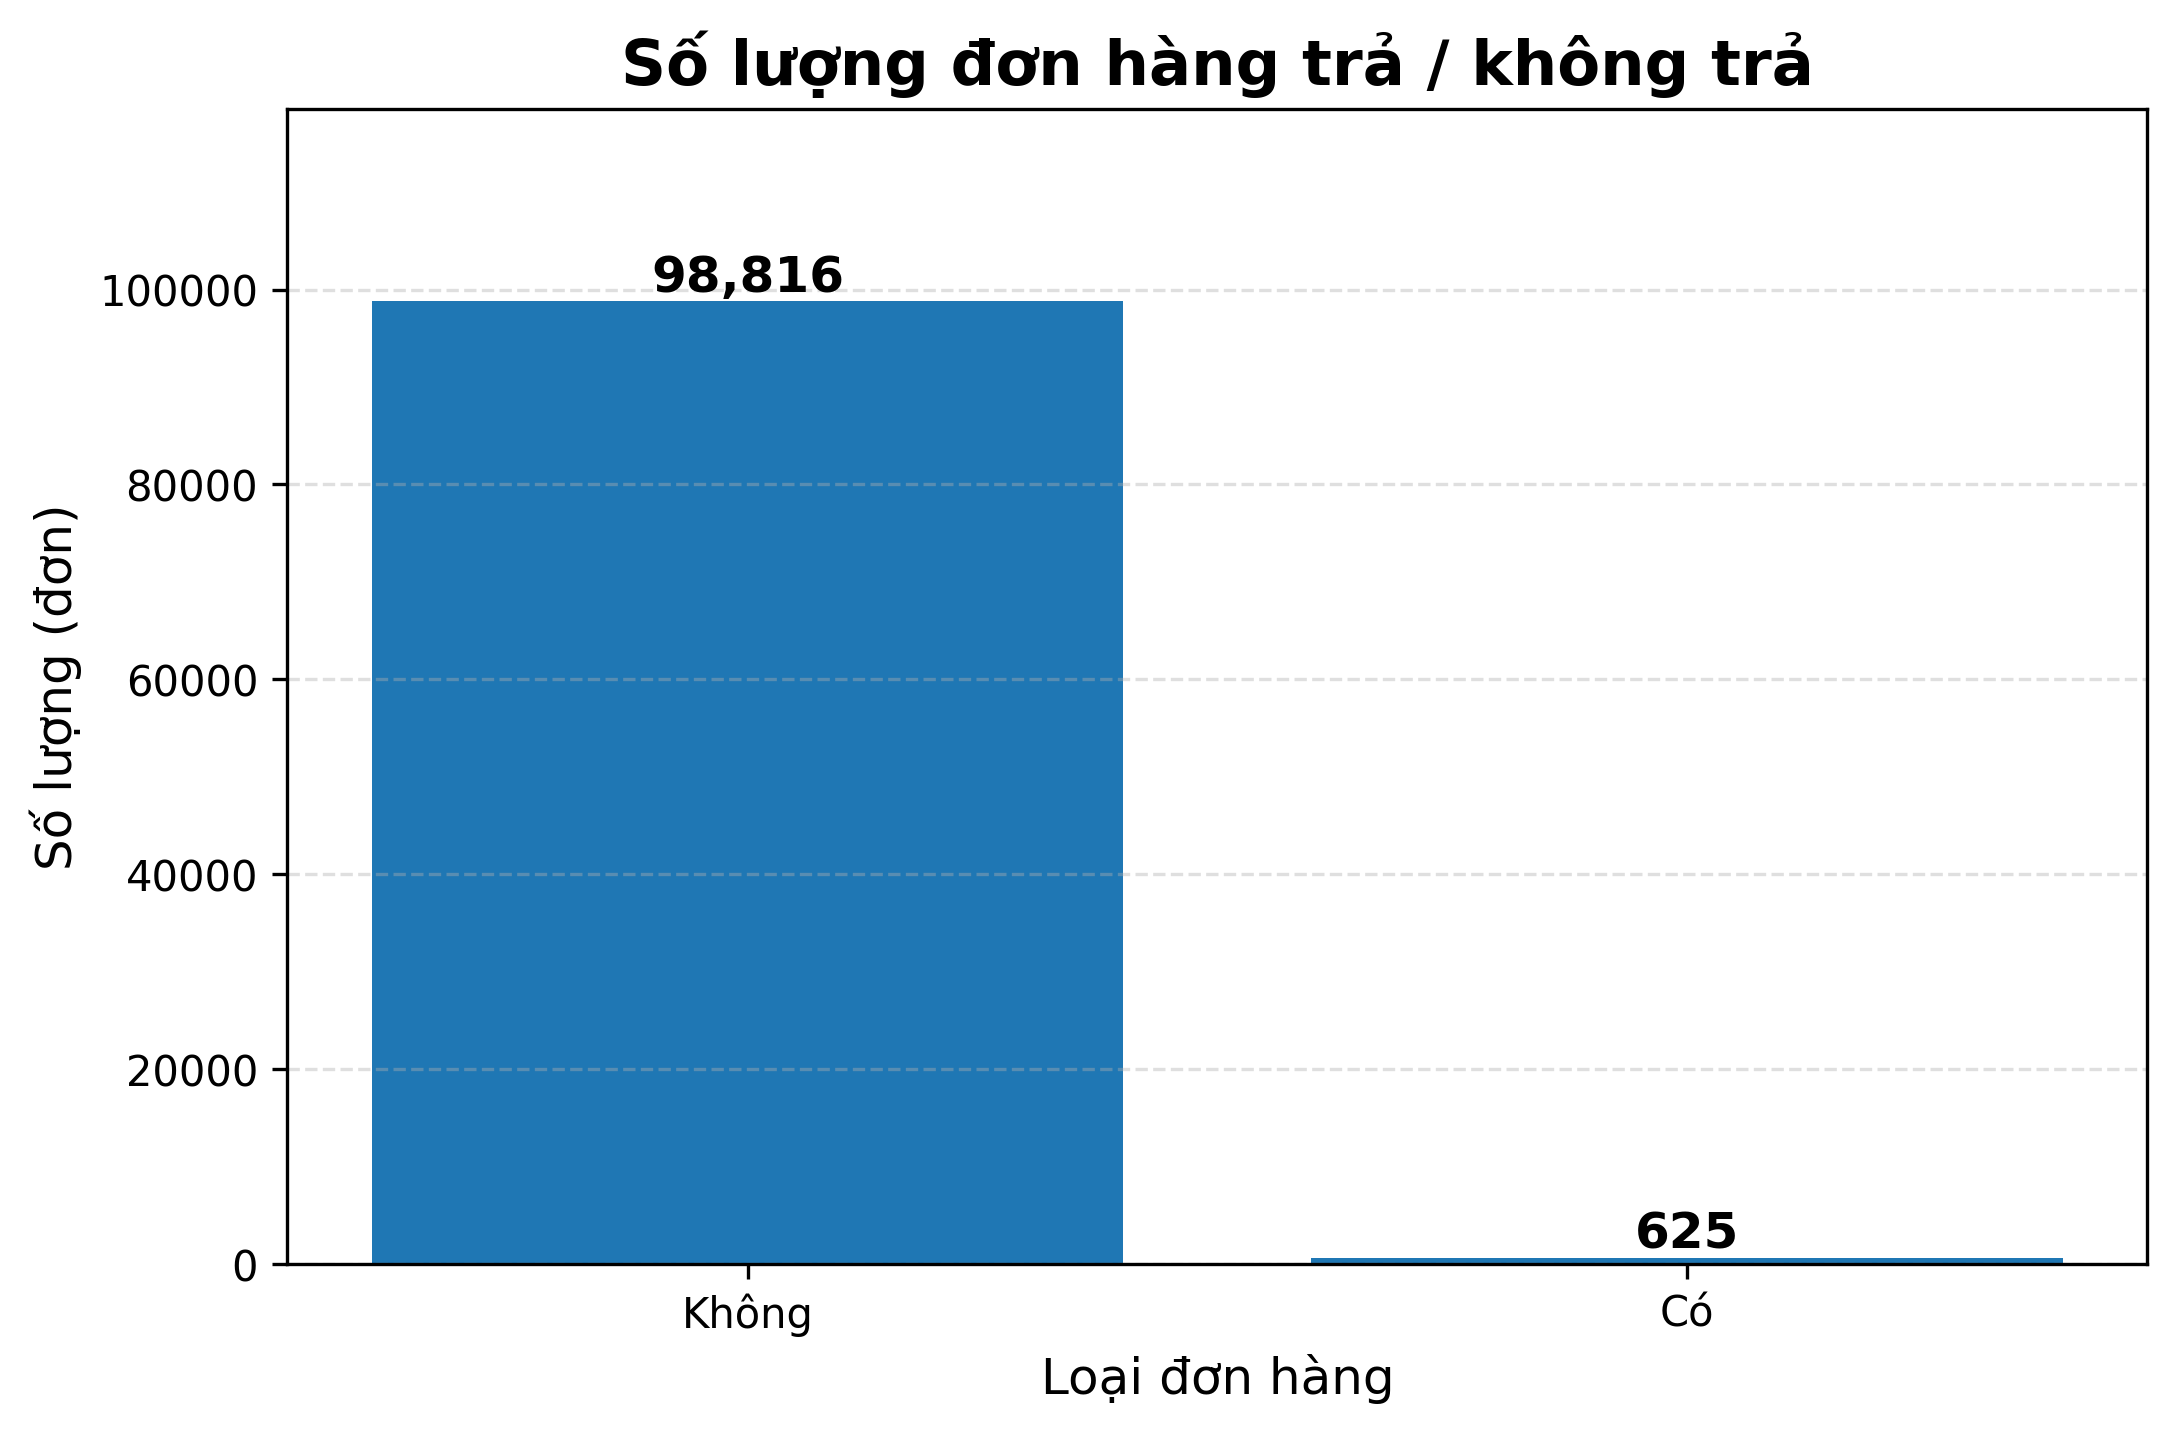

In [1]:
# Biểu đồ 1: Số lượng đơn
plt.figure(figsize=(8,5))
counts = orders['Trả hàng'].value_counts()
bars = plt.bar(counts.index, counts)
plt.title('Số lượng đơn hàng trả / không trả')
plt.show()